In [1]:
# Cella 1 — Import librerie e download fattori Fama-French Europa
import pandas as pd
import numpy as np
import yfinance as yf
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# Download fattori FF3 Europa da Kenneth French Data Library
ff3_url = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/Europe_3_Factors_daily_CSV.zip"
ff3 = pd.read_csv(ff3_url, skiprows=6, index_col=0)

# Pulizia
ff3 = ff3[ff3.index.str.strip().str.match(r'^\d{8}$')]
ff3.index = pd.to_datetime(ff3.index.str.strip(), format='%Y%m%d')
ff3.columns = ff3.columns.str.strip()
ff3 = ff3.astype(float) / 100

print(ff3.tail())
print(ff3.shape)

AttributeError: Can only use .str accessor with string values, not integer

In [2]:
import pandas as pd
import numpy as np
import yfinance as yf
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# Download fattori FF3 Europa
ff3_url = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/Europe_3_Factors_daily_CSV.zip"
ff3_raw = pd.read_csv(ff3_url, skiprows=6, index_col=0, dtype=str)

# Tieni solo le righe con date valide (8 cifre)
ff3 = ff3_raw[ff3_raw.index.str.strip().str.match(r'^\d{8}$')].copy()

# Converti indice in datetime
ff3.index = pd.to_datetime(ff3.index.str.strip(), format='%Y%m%d')
ff3.columns = ff3.columns.str.strip()
ff3 = ff3.astype(float) / 100

print(ff3.tail())
print(ff3.shape)

            Mkt-RF     SMB     HML      RF
2026-02-23 -0.0046 -0.0052  0.0084  0.0001
2026-02-24  0.0016  0.0010 -0.0030  0.0001
2026-02-25  0.0087 -0.0054  0.0091  0.0001
2026-02-26 -0.0013  0.0038  0.0016  0.0001
2026-02-27  0.0022  0.0025 -0.0067  0.0001
(9305, 4)


In [3]:
# Cella 2 — Download prezzi titoli europei con yfinance
tickers = [
    'ASML.AS', 'SAP.DE', 'NESN.SW', 'NOVN.SW', 'ROG.SW',
    'MC.PA', 'SIE.DE', 'ALV.DE', 'BNP.PA', 'DTE.DE'
]

# Scarica prezzi giornalieri adjusted
prices = yf.download(tickers, start='2010-01-01', end='2026-02-28', auto_adjust=True)['Close']

# Calcola rendimenti giornalieri
returns = prices.pct_change().dropna()

print(returns.tail())
print(f"Titoli: {returns.shape[1]}, Osservazioni: {returns.shape[0]}")

[*********************100%***********************]  10 of 10 completed

Ticker        ALV.DE   ASML.AS    BNP.PA    DTE.DE     MC.PA   NESN.SW  \
Date                                                                     
2026-02-23 -0.001055 -0.005097  0.011823  0.016198  0.005949  0.006056   
2026-02-24 -0.000792  0.011367 -0.014293  0.002105  0.006810  0.018919   
2026-02-25  0.007926  0.019788  0.020004  0.010204 -0.015664 -0.000482   
2026-02-26  0.008388 -0.043465 -0.000726 -0.022282 -0.002532 -0.002171   
2026-02-27 -0.006499  0.000811 -0.008307  0.035855 -0.013597  0.015232   

Ticker       NOVN.SW    ROG.SW    SAP.DE    SIE.DE  
Date                                                
2026-02-23  0.012020  0.007069 -0.034177 -0.018356  
2026-02-24  0.012658  0.009719 -0.012034 -0.004779  
2026-02-25  0.001543 -0.013102  0.005668  0.019207  
2026-02-26 -0.013097 -0.014901  0.032618  0.018640  
2026-02-27  0.018735  0.009351 -0.007316 -0.005027  
Titoli: 10, Osservazioni: 3975


In [4]:
# Cella 3 — Allineamento dati e stima FF3 per ogni titolo

# Allinea i due dataframe sullo stesso indice di date
combined = returns.join(ff3, how='inner')
print(f"Osservazioni dopo allineamento: {len(combined)}")

# Per ogni titolo calcola excess return e stima FF3
results = {}

for ticker in tickers:
    # Excess return = rendimento titolo - risk free
    y = combined[ticker] - combined['RF']
    
    # Fattori X con costante (alpha)
    X = sm.add_constant(combined[['Mkt-RF', 'SMB', 'HML']])
    
    # Stima OLS
    model = sm.OLS(y, X).fit()
    
    results[ticker] = {
        'alpha': model.params['const'],
        'beta_mkt': model.params['Mkt-RF'],
        'beta_smb': model.params['SMB'],
        'beta_hml': model.params['HML'],
        't_alpha': model.tvalues['const'],
        'R2': model.rsquared
    }

# Mostra risultati
results_df = pd.DataFrame(results).T.round(3)
print(results_df)

Osservazioni dopo allineamento: 3975
         alpha  beta_mkt  beta_smb  beta_hml  t_alpha     R2
ASML.AS  0.001     0.960    -0.525    -1.005    2.849  0.335
SAP.DE   0.000     0.717    -0.562    -0.701    1.883  0.368
NESN.SW  0.000     0.277    -0.825    -0.575    0.816  0.326
NOVN.SW  0.000     0.324    -0.849    -0.425    1.736  0.286
ROG.SW   0.000     0.344    -0.908    -0.638    1.016  0.292
MC.PA    0.000     0.923    -1.017    -0.680    1.912  0.526
SIE.DE   0.000     0.910    -0.554    -0.049    1.779  0.503
ALV.DE   0.000     0.786    -0.710     0.528    2.126  0.621
BNP.PA   0.000     1.033    -0.793     1.438    0.483  0.650
DTE.DE   0.000     0.438    -0.995    -0.012    1.683  0.365


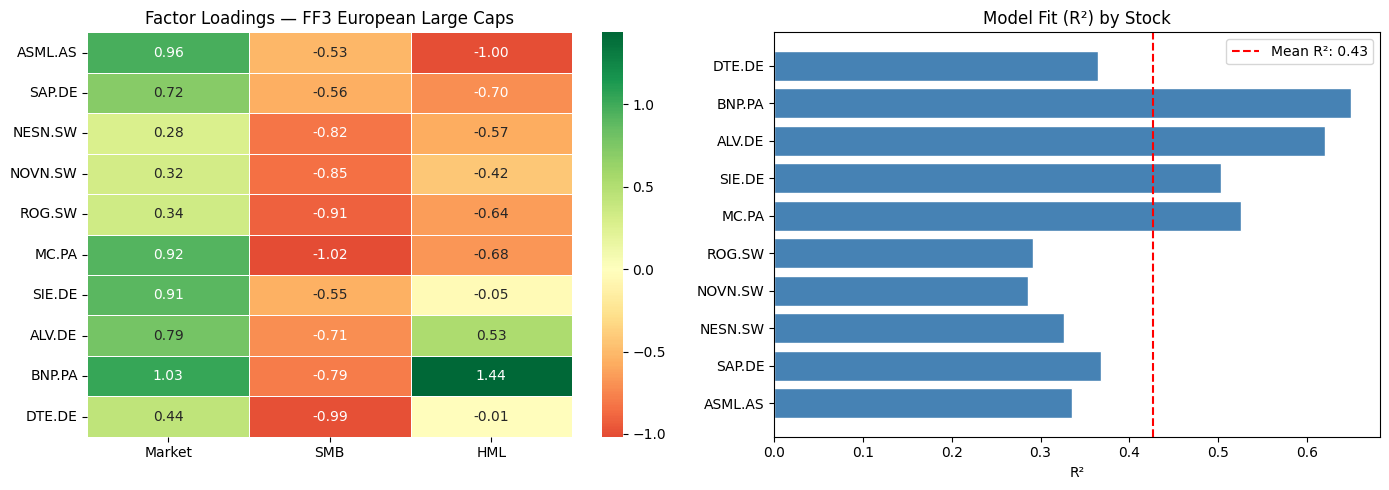

In [5]:
# Cella 4 — Heatmap delle esposizioni ai fattori
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap beta
betas = results_df[['beta_mkt', 'beta_smb', 'beta_hml']]
betas.columns = ['Market', 'SMB', 'HML']
sns.heatmap(betas, annot=True, fmt='.2f', cmap='RdYlGn', 
            center=0, ax=axes[0], linewidths=0.5)
axes[0].set_title('Factor Loadings — FF3 European Large Caps', fontsize=12)

# R² per titolo
axes[1].barh(results_df.index, results_df['R2'], color='steelblue', edgecolor='white')
axes[1].set_xlabel('R²')
axes[1].set_title('Model Fit (R²) by Stock', fontsize=12)
axes[1].axvline(x=results_df['R2'].mean(), color='red', linestyle='--', label=f'Mean R²: {results_df["R2"].mean():.2f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/ff3_factor_loadings.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# Cella 5 — Rolling betas su finestra mobile di 252 giorni (1 anno)

window = 252
ticker_plot = 'ASML.AS'  # iniziamo con ASML che aveva alpha significativo

# Prepara i dati
y_full = combined[ticker_plot] - combined['RF']
X_full = sm.add_constant(combined[['Mkt-RF', 'SMB', 'HML']])

# Calcola rolling betas
rolling_params = []

for i in range(window, len(combined)):
    y_w = y_full.iloc[i-window:i]
    X_w = X_full.iloc[i-window:i]
    model_w = sm.OLS(y_w, X_w).fit()
    rolling_params.append({
        'date': combined.index[i],
        'alpha': model_w.params['const'],
        'beta_mkt': model_w.params['Mkt-RF'],
        'beta_smb': model_w.params['SMB'],
        'beta_hml': model_w.params['HML']
    })

rolling_df = pd.DataFrame(rolling_params).set_index('date')

# Plot
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

params = ['alpha', 'beta_mkt', 'beta_smb', 'beta_hml']
colors = ['purple', 'steelblue', 'darkorange', 'green']
labels = ['Alpha', 'Beta Market', 'Beta SMB', 'Beta HML']

for ax, param, color, label in zip(axes, params, colors, labels):
    ax.plot(rolling_df.index, rolling_df[param], color=color, linewidth=1)
    ax.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
    ax.set_ylabel(label, fontsize=10)
    ax.fill_between(rolling_df.index, rolling_df[param], 0, alpha=0.1, color=color)

axes[0].set_title(f'Rolling FF3 Parameters — {ticker_plot} (252-day window)', fontsize=13)
axes[-1].set_xlabel('Date')

plt.tight_layout()
plt.savefig('../results/ff3_rolling_betas_asml.png', dpi=150, bbox_inches='tight')
plt.

SyntaxError: invalid syntax (2813841190.py, line 45)

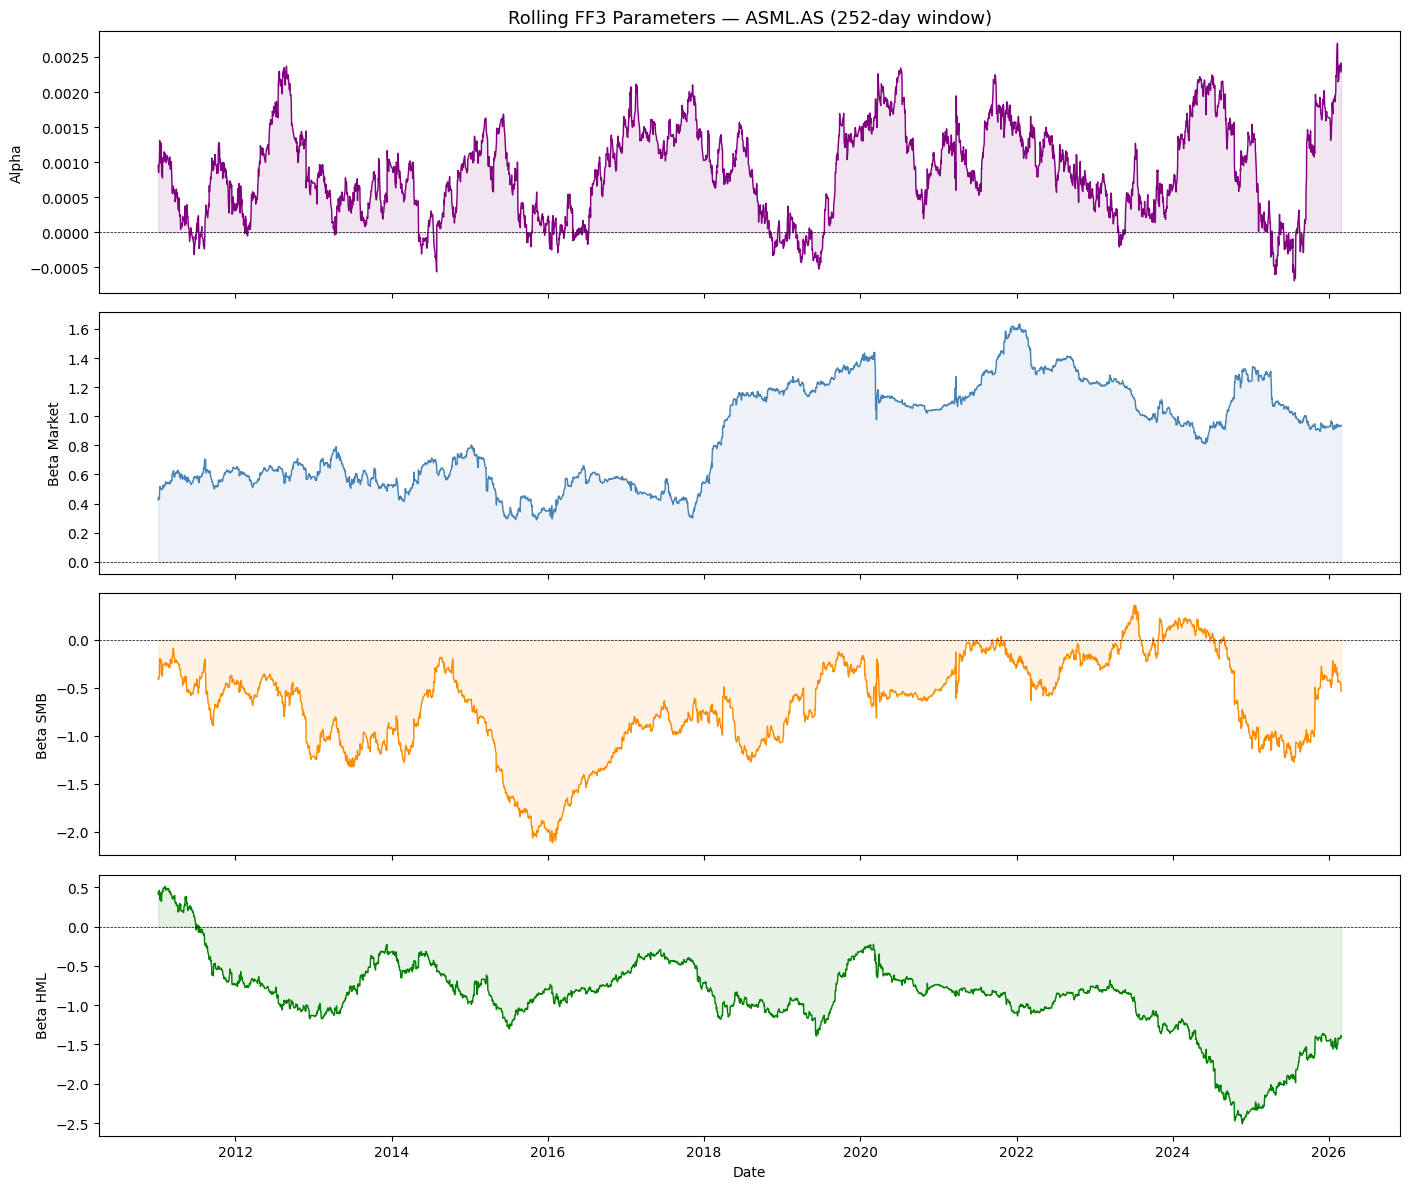

In [7]:
# Cella 5 — Rolling betas su finestra mobile di 252 giorni (1 anno)

window = 252
ticker_plot = 'ASML.AS'

y_full = combined[ticker_plot] - combined['RF']
X_full = sm.add_constant(combined[['Mkt-RF', 'SMB', 'HML']])

rolling_params = []
for i in range(window, len(combined)):
    y_w = y_full.iloc[i-window:i]
    X_w = X_full.iloc[i-window:i]
    model_w = sm.OLS(y_w, X_w).fit()
    rolling_params.append({
        'date': combined.index[i],
        'alpha': model_w.params['const'],
        'beta_mkt': model_w.params['Mkt-RF'],
        'beta_smb': model_w.params['SMB'],
        'beta_hml': model_w.params['HML']
    })

rolling_df = pd.DataFrame(rolling_params).set_index('date')

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

params_list = ['alpha', 'beta_mkt', 'beta_smb', 'beta_hml']
colors = ['purple', 'steelblue', 'darkorange', 'green']
labels = ['Alpha', 'Beta Market', 'Beta SMB', 'Beta HML']

for ax, param, color, label in zip(axes, params_list, colors, labels):
    ax.plot(rolling_df.index, rolling_df[param], color=color, linewidth=1)
    ax.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
    ax.set_ylabel(label, fontsize=10)
    ax.fill_between(rolling_df.index, rolling_df[param], 0, alpha=0.1, color=color)

axes[0].set_title(f'Rolling FF3 Parameters — {ticker_plot} (252-day window)', fontsize=13)
axes[-1].set_xlabel('Date')

plt.tight_layout()
plt.savefig('../results/ff3_rolling_betas_asml.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# Cella 6 — Carhart 4-factor: aggiungiamo WML (Winners Minus Losers)

# Scarica fattore momentum europeo da French Data Library
wml_url = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/Europe_MOM_Factor_daily_CSV.zip"
wml_raw = pd.read_csv(wml_url, skiprows=6, index_col=0, dtype=str)

wml = wml_raw[wml_raw.index.str.strip().str.match(r'^\d{8}$')].copy()
wml.index = pd.to_datetime(wml.index.str.strip(), format='%Y%m%d')
wml.columns = wml.columns.str.strip()
wml = wml.astype(float) / 100
wml.columns = ['WML']

# Unisci con i dati esistenti
combined4 = combined.join(wml, how='inner')
print(f"Osservazioni con WML: {len(combined4)}")

# Stima Carhart 4-factor per tutti i titoli
results4 = {}

for ticker in tickers:
    y = combined4[ticker] - combined4['RF']
    X = sm.add_constant(combined4[['Mkt-RF', 'SMB', 'HML', 'WML']])
    model = sm.OLS(y, X).fit()
    results4[ticker] = {
        'alpha': model.params['const'],
        'beta_mkt': model.params['Mkt-RF'],
        'beta_smb': model.params['SMB'],
        'beta_hml': model.params['HML'],
        'beta_wml': model.params['WML'],
        't_alpha': model.tvalues['const'],
        'R2': model.rsquared
    }

results4_df = pd.DataFrame(results4).T.round(3)
print(results4_df)

Osservazioni con WML: 3975
         alpha  beta_mkt  beta_smb  beta_hml  beta_wml  t_alpha     R2
ASML.AS  0.001     0.972    -0.520    -0.968     0.095    2.672  0.336
SAP.DE   0.000     0.720    -0.561    -0.692     0.023    1.822  0.368
NESN.SW  0.000     0.287    -0.821    -0.547     0.073    0.548  0.328
NOVN.SW  0.000     0.344    -0.841    -0.368     0.151    1.270  0.293
ROG.SW   0.000     0.357    -0.902    -0.600     0.099    0.728  0.295
MC.PA    0.000     0.908    -1.024    -0.725    -0.118    2.205  0.528
SIE.DE   0.000     0.905    -0.557    -0.064    -0.040    1.879  0.503
ALV.DE   0.000     0.778    -0.713     0.505    -0.062    2.322  0.622
BNP.PA   0.000     0.988    -0.812     1.306    -0.346    1.306  0.661
DTE.DE   0.000     0.447    -0.991     0.015     0.071    1.479  0.366


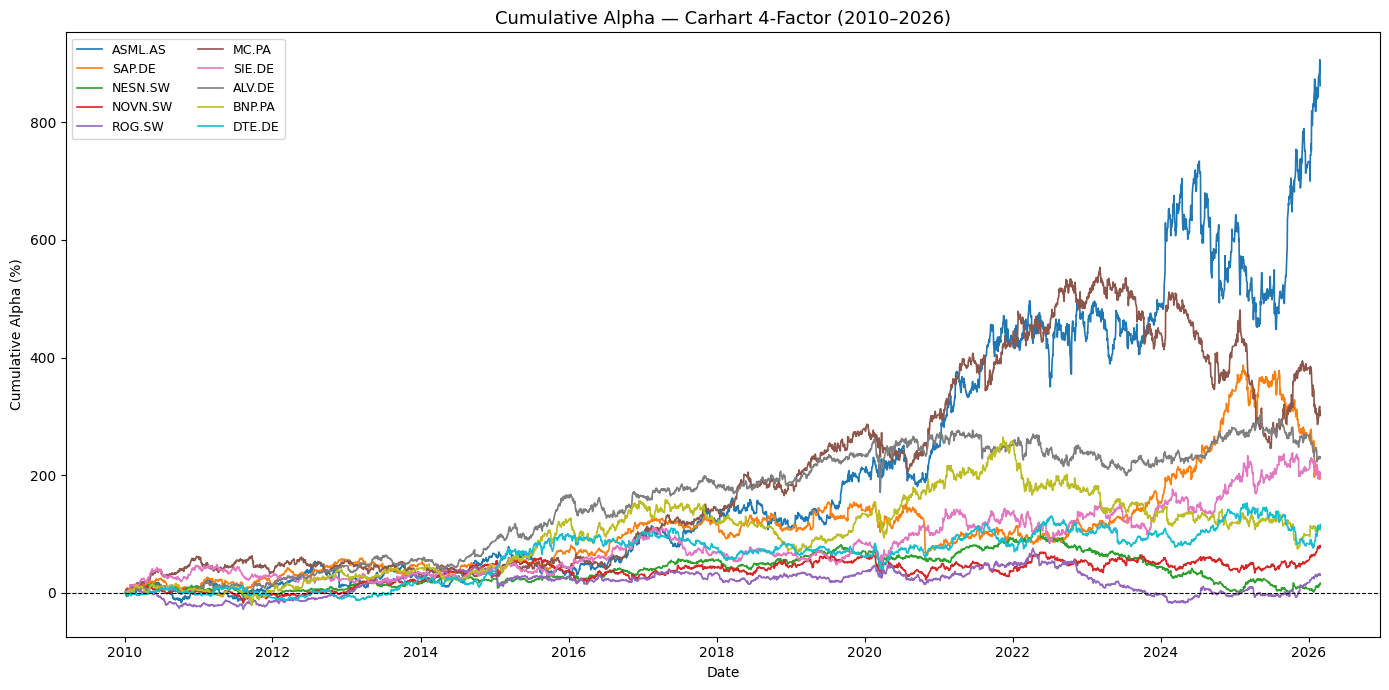

In [9]:
# Cella 7 — Alpha cumulativo nel tempo per tutti i titoli

fig, ax = plt.subplots(figsize=(14, 7))

for ticker in tickers:
    y = combined4[ticker] - combined4['RF']
    X = sm.add_constant(combined4[['Mkt-RF', 'SMB', 'HML', 'WML']])
    model = sm.OLS(y, X).fit()
    
    # Alpha giornaliero = residui + intercetta
    daily_alpha = model.resid + model.params['const']
    cumulative_alpha = (1 + daily_alpha).cumprod() - 1
    
    ax.plot(combined4.index, cumulative_alpha * 100, linewidth=1.2, label=ticker)

ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
ax.set_title('Cumulative Alpha — Carhart 4-Factor (2010–2026)', fontsize=13)
ax.set_ylabel('Cumulative Alpha (%)')
ax.set_xlabel('Date')
ax.legend(loc='upper left', fontsize=9, ncol=2)

plt.tight_layout()
plt.savefig('../results/ff3_cumulative_alpha.png', dpi=150, bbox_inches='tight')
plt.show()